In [4]:
!pip install faker plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 38.6 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
fake = Faker()

stores = ['Store_A', 'Store_B', 'Store_C', 'Store_D']
items = ['Laptop', 'Mobile', 'Tablet', 'Headphones', 'Camera']
regions = ['North', 'South', 'East', 'West']

data = []

for i in range(1000):
    date = fake.date_between(start_date='-2y', end_date='today')
    store = random.choice(stores)
    item = random.choice(items)
    region = random.choice(regions)
    sales = random.randint(10, 500)

    data.append([date, store, item, region, sales])

df = pd.DataFrame(
    data,
    columns=['Date', 'Store', 'Item', 'Region', 'Sales']
)

df.head()

,Date,Store,Item,Region,Sales
0,2025-07-30,Store_D,Laptop,South,405
1,2024-06-16,Store_B,Mobile,North,467
2,2026-05-27,Store_D,Mobile,North,119
3,2024-11-07,Store_D,Laptop,North,343
4,2025-01-28,Store_D,Camera,South,271


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

print(df.isnull().sum())

df = df.drop_duplicates()

df.info()

Date      0
Store     0
Item      0
Region    0
Sales     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1000 non-null   datetime64[ns]
 1   Store   1000 non-null   object        
 2   Item    1000 non-null   object        
 3   Region  1000 non-null   object        
 4   Sales   1000 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 39.2+ KB


In [8]:
print("Total Sales:", df['Sales'].sum())
print("Average Sales:", df['Sales'].mean())
print("Max Sales:", df['Sales'].max())
print("Min Sales:", df['Sales'].min())

Total Sales: 255931
Average Sales: 255.931
Max Sales: 500
Min Sales: 11


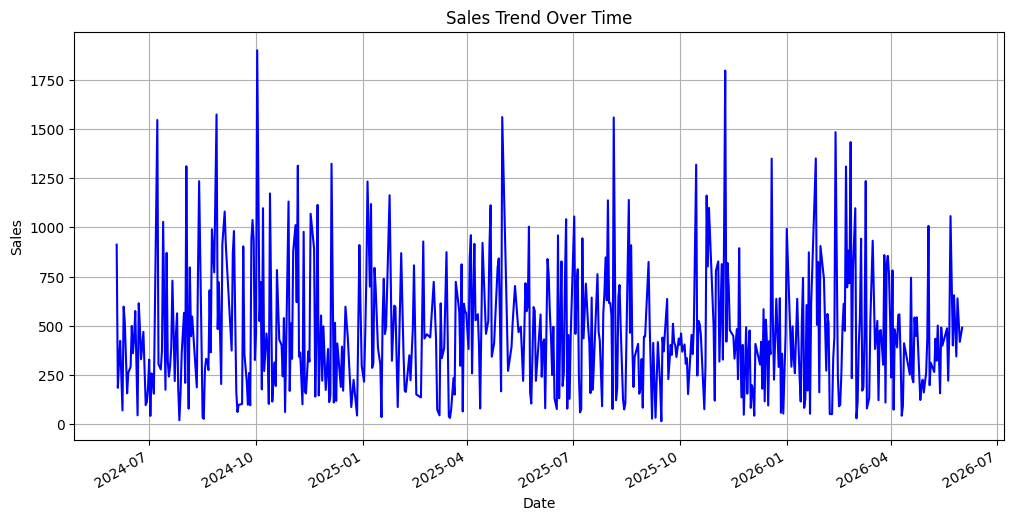

In [9]:
trend = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(12,6))
trend.plot(color='blue')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [10]:
df['Month'] = df['Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

fig = px.bar(
    monthly_sales,
    x='Month',
    y='Sales',
    color='Month',
    title='Monthly Sales Analysis'
)

fig.show()

In [11]:
store_sales = df.groupby('Store')['Sales'].sum().reset_index()

fig = px.bar(
    store_sales,
    x='Store',
    y='Sales',
    color='Store',
    title='Store Wise Sales'
)

fig.show()

In [12]:
item_sales = df.groupby('Item')['Sales'].sum().reset_index()

fig = px.bar(
    item_sales,
    x='Item',
    y='Sales',
    color='Item',
    title='Product Wise Sales'
)

fig.show()

In [13]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

fig = px.pie(
    region_sales,
    values='Sales',
    names='Region',
    title='Sales Distribution By Region'
)

fig.show()

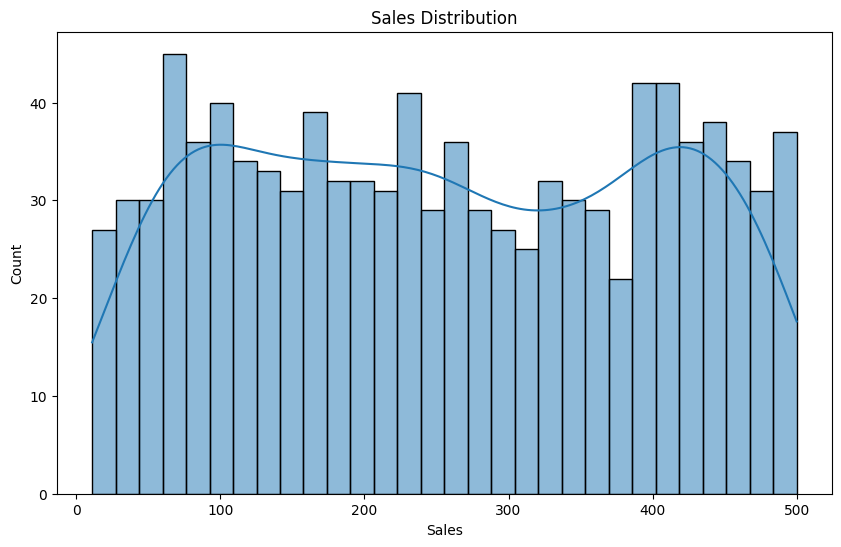

In [14]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Sales',
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.show()

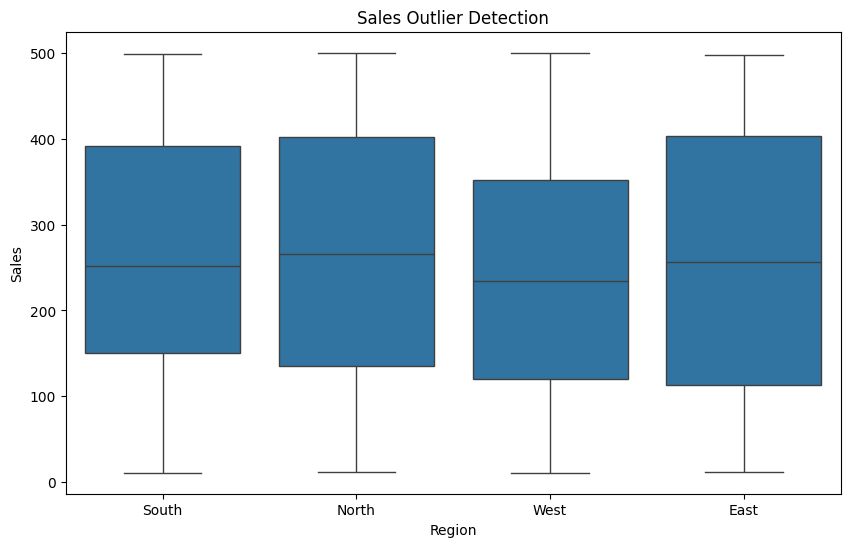

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Region',
    y='Sales'
)

plt.title("Sales Outlier Detection")
plt.show()

In [16]:
top_products = (
    df.groupby('Item')['Sales']
    .sum()
    .sort_values(ascending=False)
)

print(top_products)

Item
Mobile        61521
Laptop        51118
Tablet        49677
Camera        48912
Headphones    44703
Name: Sales, dtype: int64


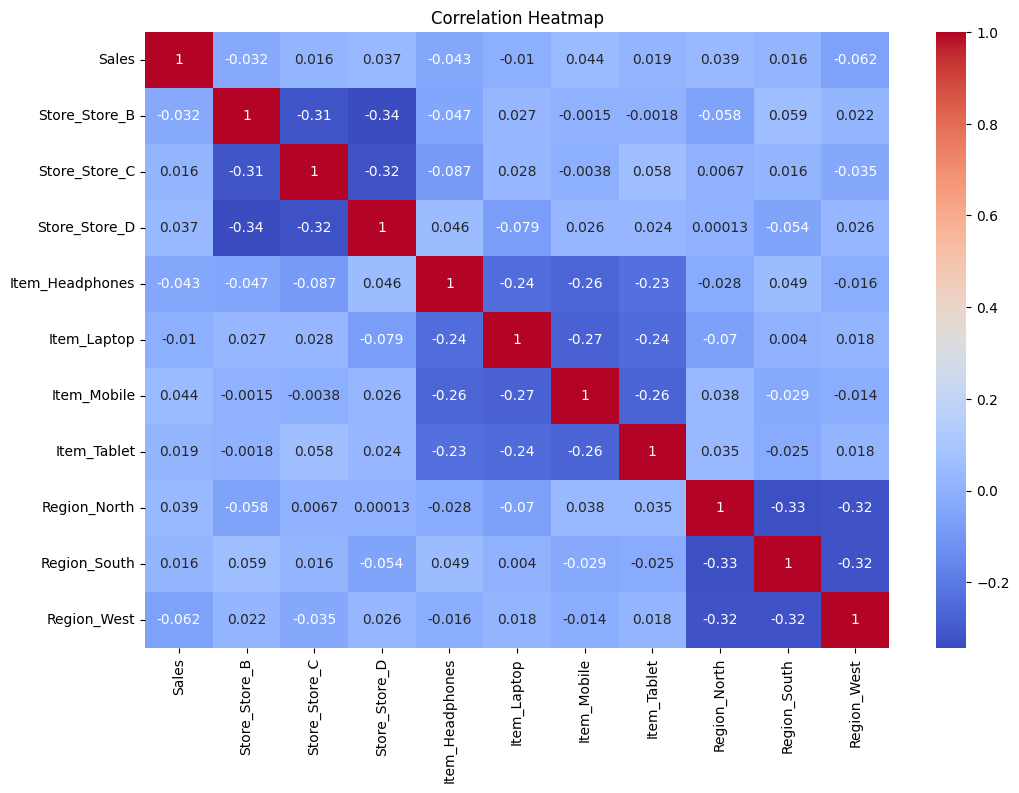

In [17]:
categorical_cols = ['Store', 'Item', 'Region']

encoded = pd.get_dummies(
    df[categorical_cols],
    drop_first=True
)

corr_df = pd.concat(
    [df[['Sales']], encoded],
    axis=1
)

corr = corr_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [19]:
best_store = store_sales.loc[
    store_sales['Sales'].idxmax(),
    'Store'
]

best_product = item_sales.loc[
    item_sales['Sales'].idxmax(),
    'Item'
]

best_region = region_sales.loc[
    region_sales['Sales'].idxmax(),
    'Region'
]

print("Best Performing Store:", best_store)
print("Best Selling Product:", best_product)
print("Highest Revenue Region:", best_region)

Best Performing Store: Store_D
Best Selling Product: Mobile
Highest Revenue Region: East
